# Task 6: Web Scraping and Analysis of Job Postings
**Tools Used:** Python | BeautifulSoup | Pandas | Matplotlib

**Author:** `Awais Manzoor `

# Step 1: Scrape Data
  - We will fetch job postings from the Fake Jobs website using `requests` and `BeautifulSoup`.

In [6]:

import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import re

# Scrape the website
url = "https://realpython.github.io/fake-jobs/"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

# Extract job postings
jobs = soup.find_all("div", class_="card-content")

job_list = []
for job in jobs:
    title = job.find("h2", class_="title").get_text(strip=True)
    company = job.find("h3", class_="company").get_text(strip=True)
    location = job.find("p", class_="location").get_text(strip=True)
    posted = job.find("time")["datetime"]

    # Extract skills from job title using regex
    skills = []
    if re.search(r'python', title, re.I):
        skills.append("Python")
    if re.search(r'data|analysis|analytics', title, re.I):
        skills.append("Data Analysis")
    if re.search(r'javascript', title, re.I):
        skills.append("JavaScript")
    if re.search(r'devops', title, re.I):
        skills.append("DevOps")

    job_list.append({
        "title": title,
        "company": company,
        "location": location,
        "posted_date": posted,
        "skills": skills if skills else ["General"]
    })


# Step 2: Create DataFrame

 - Convert the scraped data into a Pandas DataFrame.

In [7]:
df = pd.DataFrame(job_list)
print("Sample Data:\n", df.head())


Sample Data:
                      title                     company              location  \
0  Senior Python Developer    Payne, Roberts and Davis       Stewartbury, AA   
1          Energy engineer            Vasquez-Davidson  Christopherville, AA   
2          Legal executive  Jackson, Chambers and Levy   Port Ericaburgh, AA   
3   Fitness centre manager              Savage-Bradley     East Seanview, AP   
4          Product manager                 Ramirez Inc   North Jamieview, AP   

  posted_date     skills  
0  2021-04-08   [Python]  
1  2021-04-08  [General]  
2  2021-04-08  [General]  
3  2021-04-08  [General]  
4  2021-04-08  [General]  


# Step 3: Skill Frequency Analysis

  - Count how often each skill appears in job postings.

In [8]:
all_skills = df.explode("skills")
skill_counts = all_skills["skills"].value_counts()

print("\nMost In-Demand Skills:\n", skill_counts)



Most In-Demand Skills:
 skills
General          88
Python           10
Data Analysis     2
Name: count, dtype: int64


# Step 4: Visualization of Skills

  - Visualize the Top 5 Most In-Demand Skills using a bar chart.

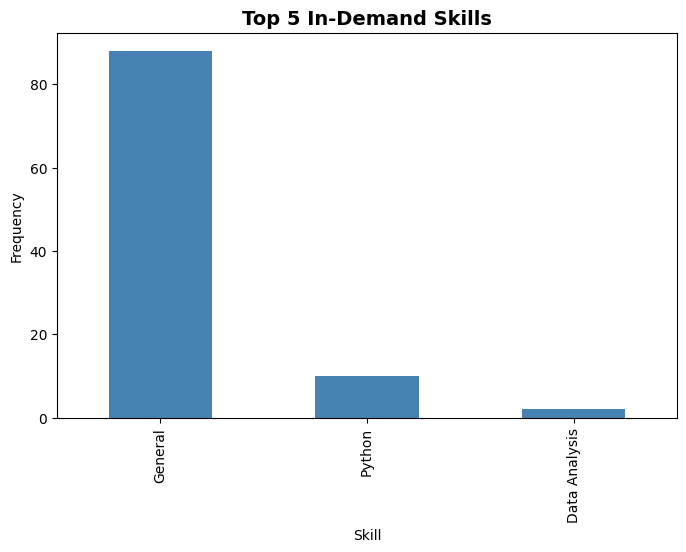

In [9]:
plt.figure(figsize=(8,5))
skill_counts.head(5).plot(kind="bar", color="steelblue")
plt.title("Top 5 In-Demand Skills", fontsize=14, weight="bold")
plt.xlabel("Skill")
plt.ylabel("Frequency")
plt.show()


# Step 5: City-wise Skill Mentions

  - Analyze how skills are distributed across different cities.

In [10]:
city_skills = all_skills.groupby("location")["skills"].value_counts().unstack().fillna(0)
city_totals = city_skills.sum(axis=1).sort_values(ascending=False).head(5)


# Step 6: Skill Distribution by City

  - Plot a stacked bar chart of skills across the Top 5 Cities.

<Figure size 1200x600 with 0 Axes>

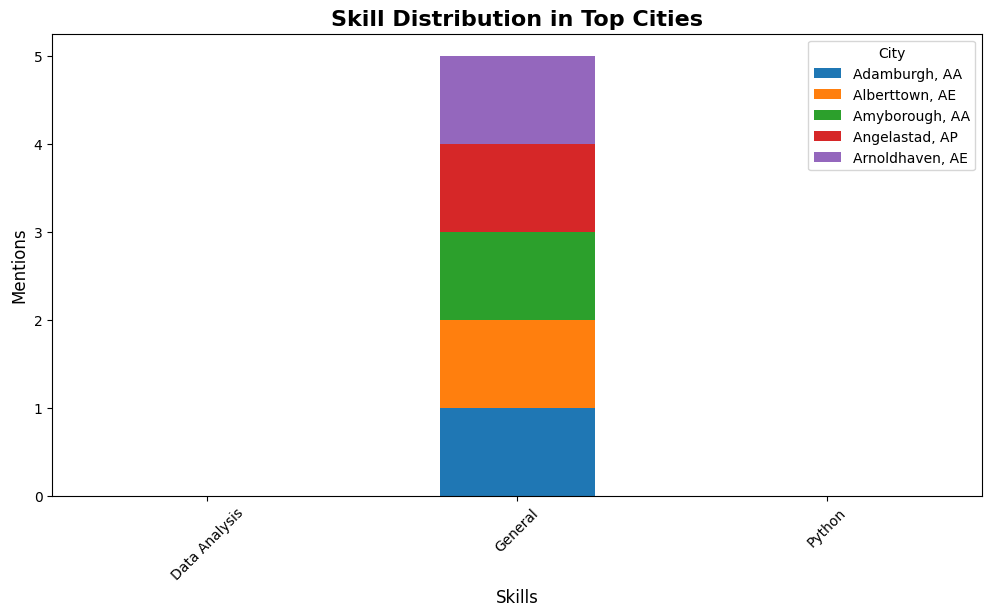

In [11]:
if city_skills.empty:
    print("No city-skill breakdown available to plot.")
else:
    plt.figure(figsize=(12, 6))
    city_skills.loc[city_totals.index].T.plot(kind="bar", stacked=True, figsize=(12, 6))
    plt.title("Skill Distribution in Top Cities", fontsize=16, fontweight="bold")
    plt.xlabel("Skills", fontsize=12)
    plt.ylabel("Mentions", fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title="City")
    plt.show()


# Step 7: Top Cities with Most Job Postings

  - Plot the Top Cities with the highest number of job postings.

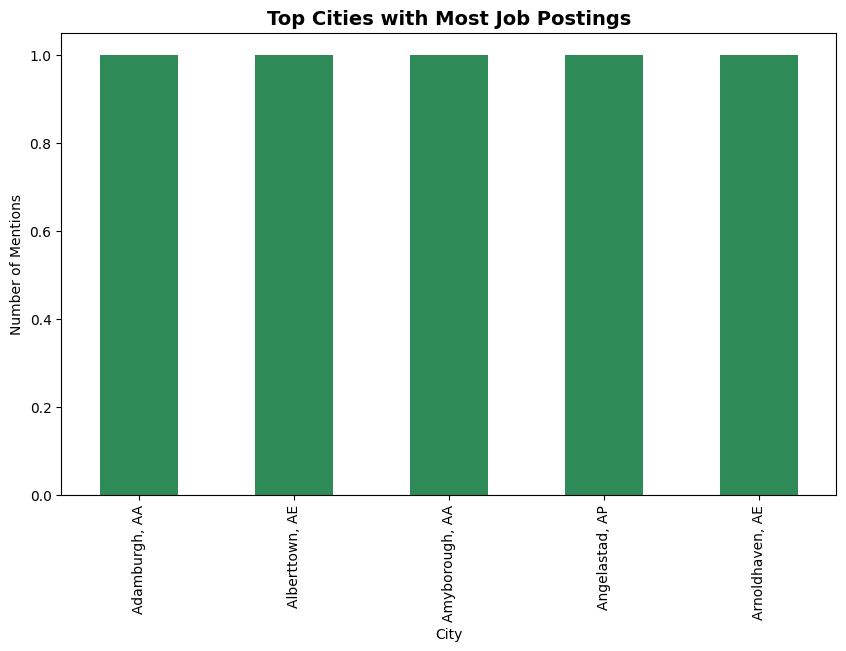

In [12]:
plt.figure(figsize=(10,6))
city_totals.plot(kind="bar", color="seagreen")
plt.title("Top Cities with Most Job Postings", fontsize=14, weight="bold")
plt.xlabel("City")
plt.ylabel("Number of Mentions")
plt.show()
